In [66]:
import numpy as np
np.random.seed(42)
n = 1000
p = 5
beta_true = np.array([0.5,1,-1,1.2,1,3]) # 截距 + 5个系数

# 构造基底相关矩阵,协方差矩阵
rho = 0.2 # 相邻变量相关系数
sigma = np.zeros((p,p))
for i in range(p):
    for j in range(p):
        sigma[i,j] = rho ** abs(i-j)

# 按多元正太分布生成自变量
mean = np.zeros(p) # 均值向量
X_raw = np.random.multivariate_normal(mean,sigma,size=n)

# 添加截距项，horizontal stack（水平堆叠）
X = np.hstack([np.ones((n,1)),X_raw]) # 最左边添加一列全1，为了和截距相乘

# 计算线性预测值
z = X @ beta_true

# 转化为概率 p = 1/(1+e^{-z})
p = 1 / (1 + np.exp(-z))   # p是一个n维列向量

# 生成二分类标签y
y = np.random.binomial(1,p)

# 检查y的比例
print(f'y=1的比例：{y.mean():.3f}')

y=1的比例：0.547


In [70]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(X,y,beta):
    p = sigmoid(X @ beta)
    eps = 1e-10 # 避免log（0）的情况
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    return loss

def compute_gradient(X,y,beta,n):
    p = sigmoid(X @ beta)
    return X.T @ (p - y) / n

def gradient_descent(X,y,beta_init,learning_rate,max_iter,tol,n):
    beta = beta_init.copy()
    loss_history = []

    for i in range(max_iter):
        loss = compute_loss(X,y,beta) # 计算平均损失
        loss_history.append(loss)

        grad = compute_gradient(X,y,beta,n) # 计算平均梯度
        beta_new  = beta - learning_rate * grad # 优化参数

        if np.linalg.norm(beta_new - beta)<tol:
            print(f'收敛于第{i+1}次迭代')
            beta = beta_new
            break

        beta = beta_new

        if i % 100 == 0:
            print(f'迭代第{i+1}次，损失为{loss:.6f}')
    return beta,loss_history,i+1

In [71]:
def compute_hessian(X,y,beta,n):
    p = sigmoid(X @ beta)
    w = p * (1 - p)
    W = np.diag(w)
    hessian = X.T @ W @ X / n
    return hessian

def newton_method(X,y,beta_init,max_iter,tol,n):
    p = sigmoid(X @ beta_init)
    beta = beta_init.copy()
    loss_history = []

    for i in range(max_iter):
        loss = compute_loss(X,y,beta)
        loss_history.append(loss)

        grad = compute_gradient(X,y,beta,n)
        hessian = compute_hessian(X,y,beta,n)

        # 参数迭代方程 beta_new = beta - H^{-1} * grad

        try:
            delta = np.linalg.solve(hessian,-grad)  # delta = -H^{-1} * grad
        except np.linalg.LinAlgError:
            print('Hessian 矩阵奇异，无法求逆')
            break

        beta_new  = beta + delta # 优化

        if np.linalg.norm(beta_new - beta)<tol:
            print(f'收敛于第{i+1}次迭代')
            beta = beta_new
            break

        beta = beta_new

        if (i+1) % 5 == 0:
            print(f"迭代 {i+1}: 损失 = {loss:.6f}")

    return beta,loss_history,i+1


In [72]:
import matplotlib.pyplot as plt

# 初始化参数
beta_init = np.zeros(6)

# 梯度下降法参数
learning_rate = 0.5
max_iter_grad = 1000
tol_grad = 1e-6

# 牛顿法参数
max_iter_newton = 100
tol_newton = 1e-6

print('运行梯度下降算法')
beta_grad,loss_history_grad,i_grad = gradient_descent(X,y,beta_init,learning_rate,max_iter_grad,tol_grad,n)

print("="*20)
print('运行牛顿法')
beta_new,loss_history_new,i_new = newton_method(X,y,beta_init,max_iter_newton,tol_newton,n)

运行梯度下降算法
迭代第1次，损失为0.693147
迭代第101次，损失为0.285106
迭代第201次，损失为0.279882
迭代第301次，损失为0.279116
迭代第401次，损失为0.278966
迭代第501次，损失为0.278934
迭代第601次，损失为0.278927
迭代第701次，损失为0.278925
迭代第801次，损失为0.278925
迭代第901次，损失为0.278925
运行牛顿法
迭代 5: 损失 = 0.279013
收敛于第8次迭代


In [80]:
print(f"梯度下降法估计值：\n{beta_grad}，\n真值：{beta_true}，\n损失：{loss_history_grad[-1]}")

梯度下降法估计值：
[ 0.44278552  0.92203137 -0.8906784   1.20125416  1.04154878  3.31388095]，
真值：[ 0.5  1.  -1.   1.2  1.   3. ]，
损失：0.27892498679362326


In [81]:
print(f"牛顿法法估计值：\n{beta_new}，\n真值：{beta_true}，\n损失：{loss_history_new[-1]:.6f}")

牛顿法法估计值：
[ 0.4428885   0.92225363 -0.89090922  1.20155887  1.04175182  3.31466631]，
真值：[ 0.5  1.  -1.   1.2  1.   3. ]，
损失：0.278925


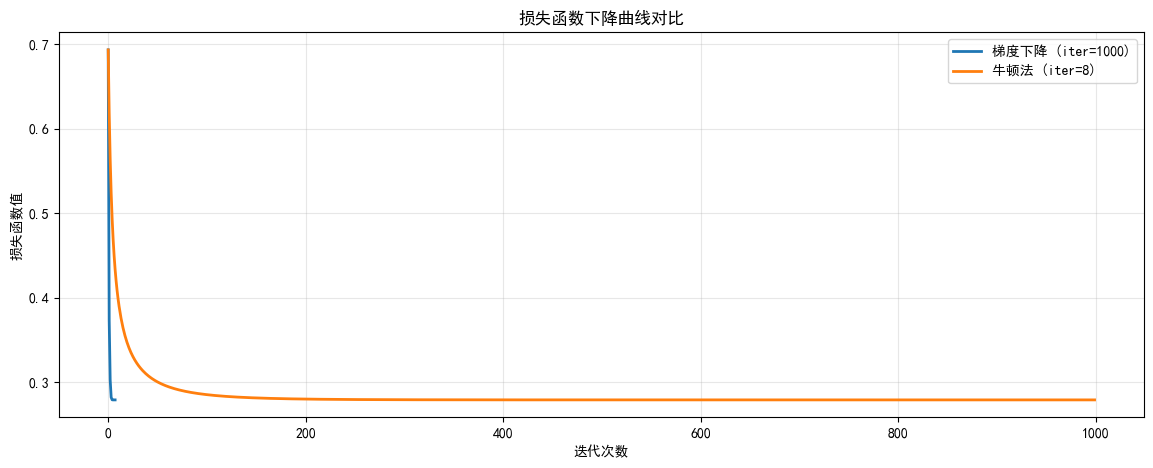

In [83]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 5))
plt.plot(loss_history_grad, label=f'梯度下降 (iter={i_grad})', linewidth=2)
plt.plot(loss_history_new, label=f'牛顿法 (iter={i_new})', linewidth=2)
plt.xlabel('迭代次数')
plt.ylabel('损失函数值')
plt.title('损失函数下降曲线对比')
plt.legend()
plt.grid(True, alpha=0.3)